In [47]:
#CELL 1 — Import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    ConfusionMatrixDisplay,
    precision_score, recall_score,
    f1_score, accuracy_score
)

from sklearn.feature_selection import mutual_info_classif

In [48]:
#CELL 2 — Load, Cleaning & Preprocessing

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# convert numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# missing value
df.dropna(inplace=True)

# drop id column
df.drop(columns=['customerID'], inplace=True)

# encoding target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Outlier Handling (IQR - clipping agar aman secara data mining)
for col in ['tenure', 'MonthlyCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

print(df.shape)

(7032, 20)


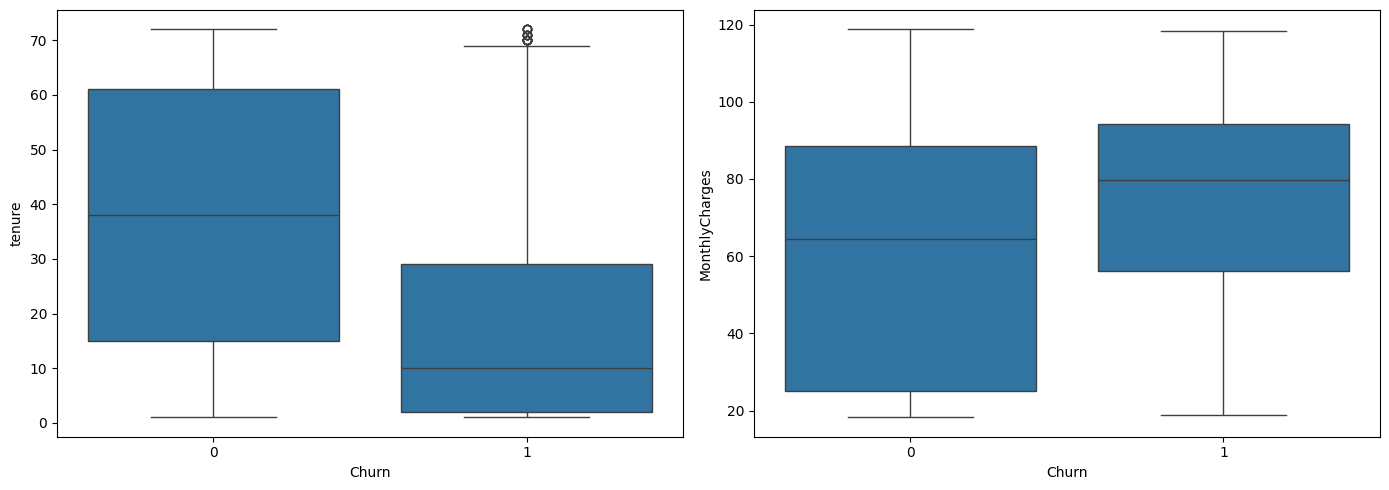

In [49]:
#CELL 3 - EDA

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])

plt.tight_layout()
plt.show()

In [50]:
#CELL 4 - Encoding & Split (Persiapan Data)

categorical_cols = df.select_dtypes(include='object').columns.tolist()

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

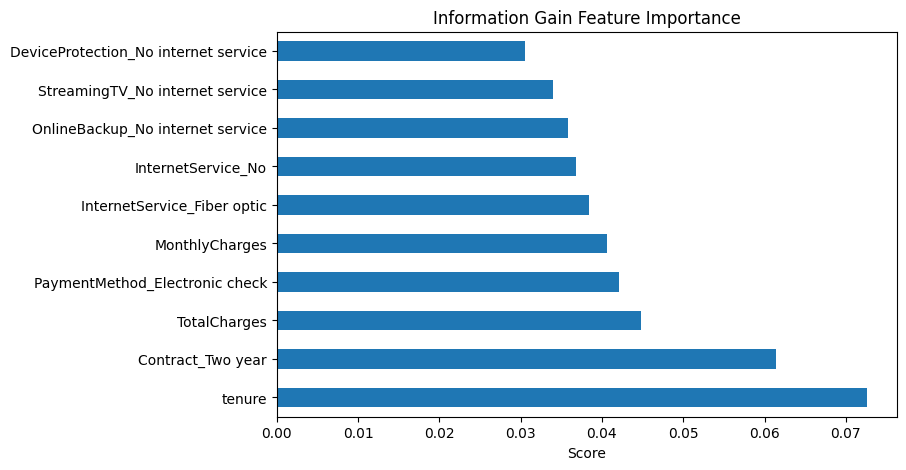

In [51]:
#4.1 FEATURE SELECTION (INFORMATION GAIN)
mi_scores = mutual_info_classif(X_train, y_train)

mi_result = pd.Series(mi_scores, index=X.columns)

mi_result.sort_values(ascending=False).head(10).plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Information Gain Feature Importance")
plt.xlabel("Score")
plt.show()

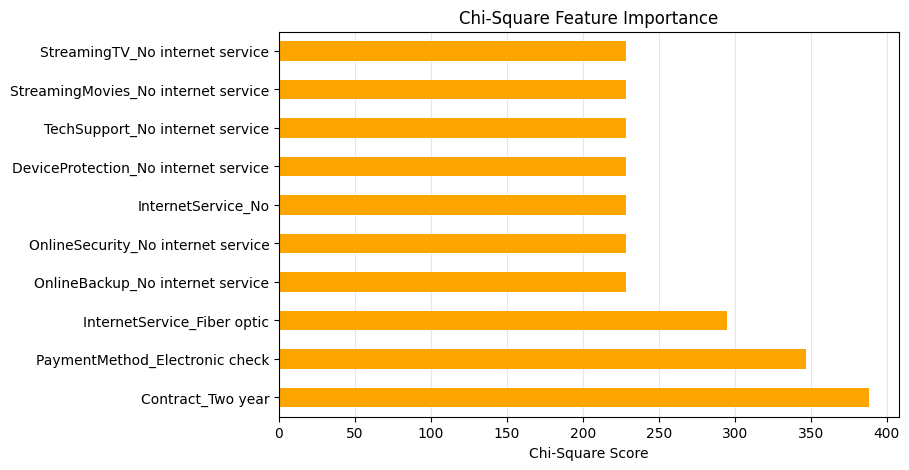

In [52]:
#4.2 CHI-SQUARE FEATURE SELECTION
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# Scaling khusus Chi-Square
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Hitung skor Chi-Square
chi_scores, p_values = chi2(X_train_scaled, y_train)

# Convert ke Series
chi_result = pd.Series(
    chi_scores,
    index=X.columns
)

# Visualisasi
plt.figure(figsize=(8,5))

chi_result.sort_values(ascending=False).head(10).plot(
    kind='barh',
    color='orange'
)

plt.title("Chi-Square Feature Importance")
plt.xlabel("Chi-Square Score")

plt.grid(axis='x', alpha=0.3)

plt.show()

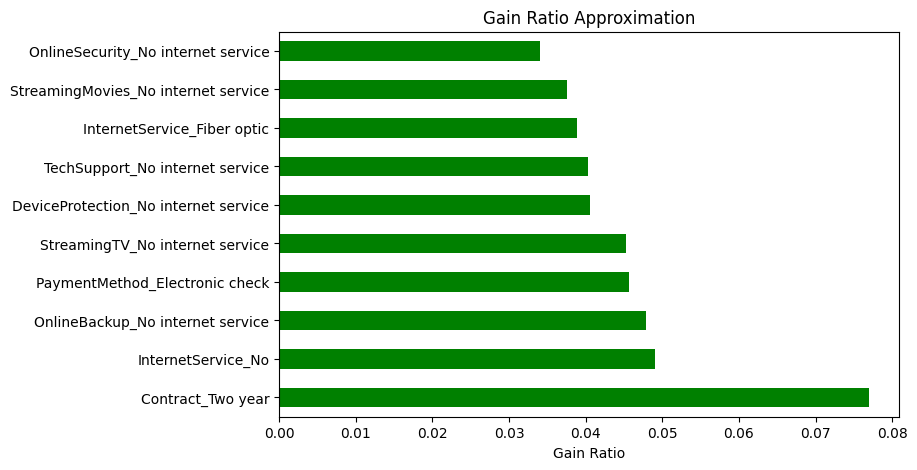

In [53]:
#4.3 Gain Ration
def gain_ratio(info_gain, split_info):
    if split_info == 0:
        return 0
    return info_gain / split_info

gain_ratio_scores = {}

for col in X_train.columns:
    
    probs = X_train[col].value_counts(normalize=True)

    split_info = -np.sum(probs * np.log2(probs + 1e-9))

    info_gain = mi_result[col]

    gain_ratio_scores[col] = gain_ratio(info_gain, split_info)

gain_ratio_series = pd.Series(gain_ratio_scores)

gain_ratio_series.sort_values(ascending=False).head(10).plot(
    kind='barh',
    figsize=(8,5),
    color='green'
)

plt.title("Gain Ratio Approximation")
plt.xlabel("Gain Ratio")
plt.show()

In [54]:
#4.4 Decision Tree
dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

print(dt)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)


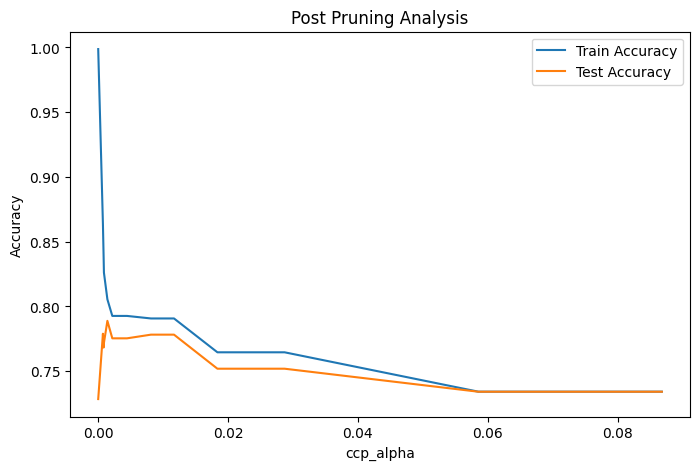

In [55]:
#4.5 Post-Prunning
path = dt.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

models = []

for alpha in ccp_alphas:

    clf = DecisionTreeClassifier(
        criterion='entropy',
        ccp_alpha=alpha,
        random_state=42
    )

    clf.fit(X_train, y_train)

    models.append(clf)

train_scores = [clf.score(X_train, y_train) for clf in models]
test_scores = [clf.score(X_test, y_test) for clf in models]

plt.figure(figsize=(8,5))

plt.plot(ccp_alphas, train_scores, label='Train Accuracy')
plt.plot(ccp_alphas, test_scores, label='Test Accuracy')

plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Post Pruning Analysis')

plt.legend()
plt.show()

In [56]:
#CELL 5 - MODELING
rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        criterion='entropy',
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt'
    ))
])

param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

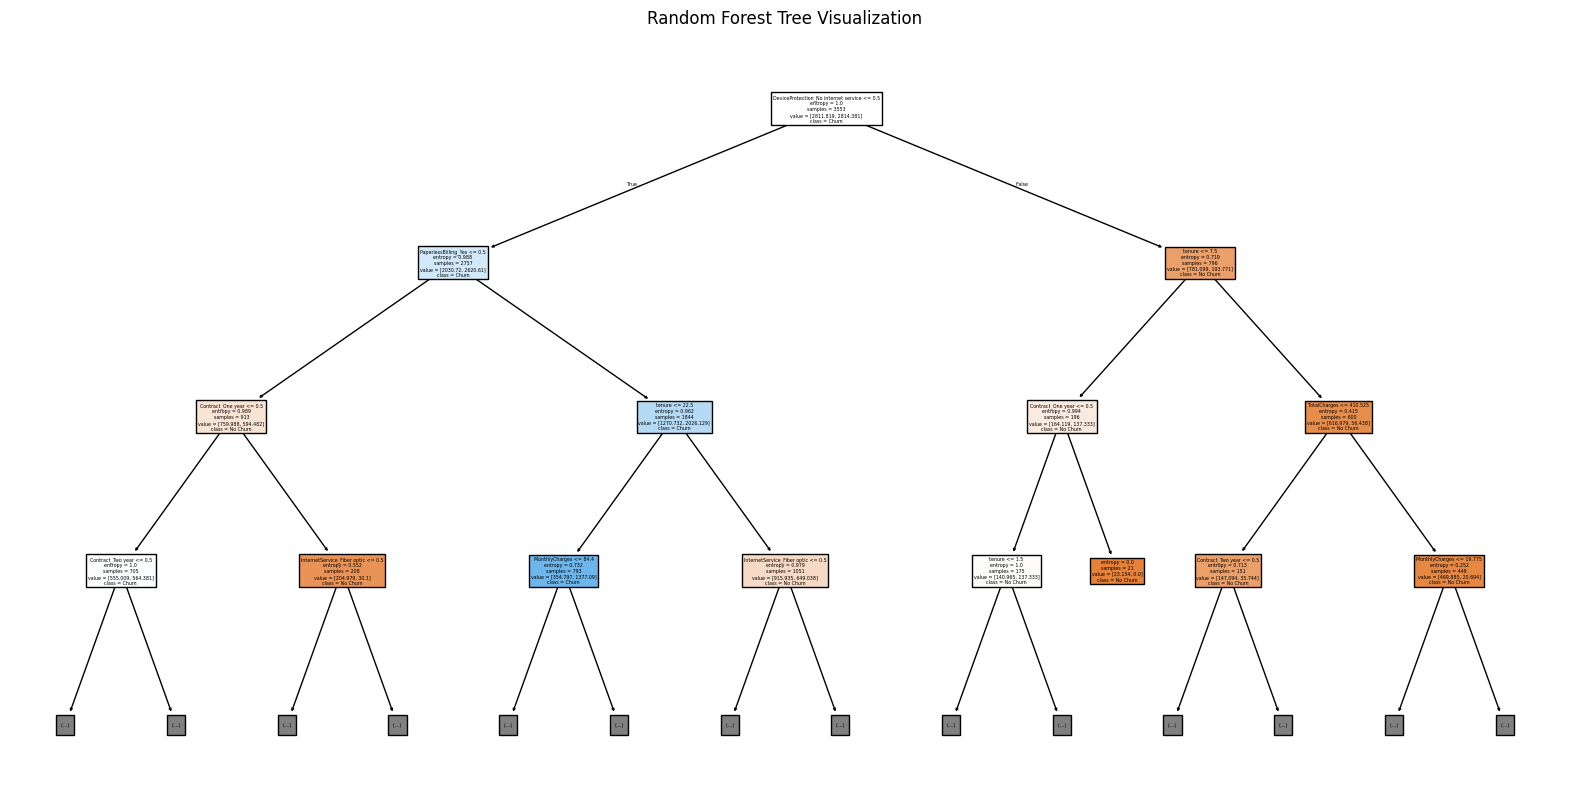

In [57]:
#Visualisasi Decision Tree
# Ambil salah satu tree dari Random Forest
rf_model = best_rf.named_steps['rf']

tree = rf_model.estimators_[0]

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    max_depth=3,
    filled=True
)

plt.title("Random Forest Tree Visualization")

plt.show()

In [58]:
# CELL 6 — Evaluasi & Perbandingan Model

# PREDIKSI MODEL
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

# METRIK EVALUASI
results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

print("=== HASIL EVALUASI TEST SET ===")
print(results)

# CLASSIFICATION REPORT
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

print("\n=== CROSS VALIDATION ROC-AUC ===")
print("Scores tiap fold:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

=== HASIL EVALUASI TEST SET ===
{'Accuracy': 0.759772565742715, 'Precision': np.float64(0.533210332103321), 'Recall': np.float64(0.7727272727272727), 'F1': np.float64(0.631004366812227), 'ROC-AUC': np.float64(0.837958337431602)}

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1033
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.77      1407


=== CROSS VALIDATION ROC-AUC ===
Scores tiap fold: [0.84844775 0.85209607 0.84547337 0.84607921 0.84051139]
Mean ROC-AUC: 0.8465215580384007
Std ROC-AUC: 0.003800049628364822


In [59]:
#6.1 Overfitting Check
print("Train Acc:", best_rf.score(X_train, y_train))
print("Test Acc:", best_rf.score(X_test, y_test))

Train Acc: 0.8174222222222223
Test Acc: 0.759772565742715


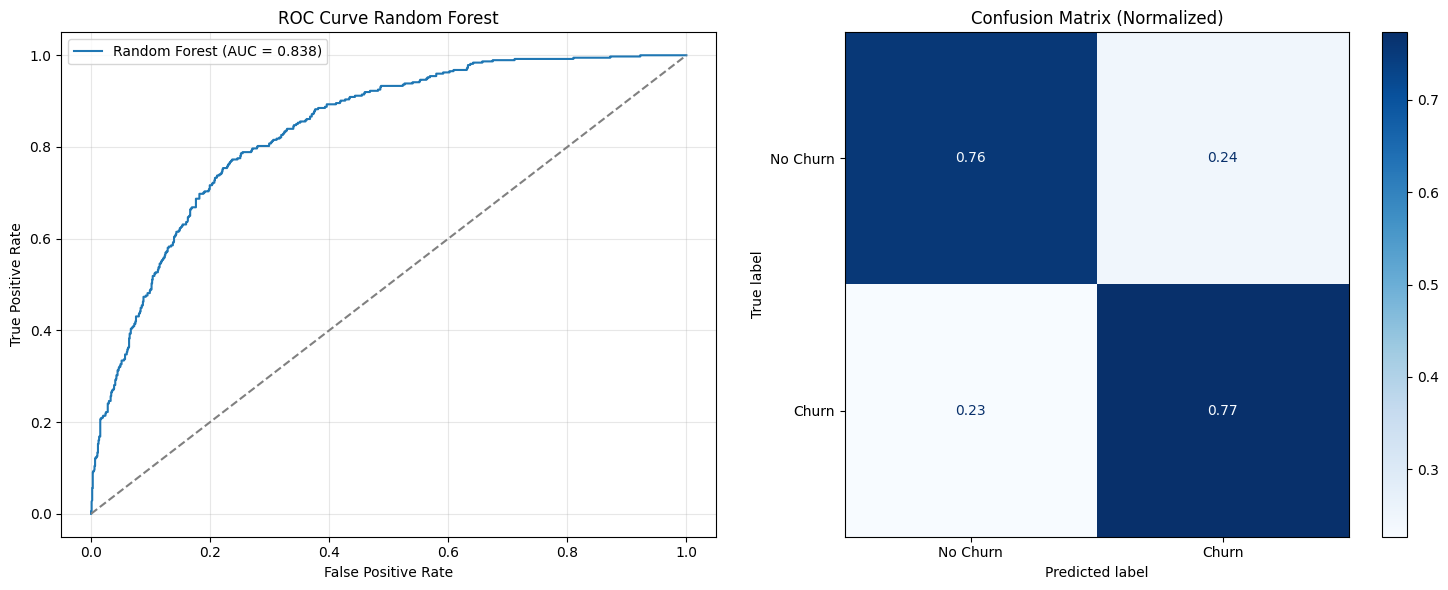

Confusion Matrix (Raw Values):
[[780 253]
 [ 85 289]]


In [60]:
#CELL 7 Visualisasi
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# =========================
# ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob)

axes[0].plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray')

axes[0].set_title('ROC Curve Random Forest')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

# =========================
# CONFUSION MATRIX (VISUAL)
# =========================
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Churn', 'Churn'],
    normalize='true',
    ax=axes[1],
    cmap='Blues'
)

axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()


# =========================
# CONFUSION MATRIX (RAW NUMBERS)
# =========================
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (Raw Values):")
print(cm)

In [61]:
#Business Insight

X_test_copy = X_test.copy()
X_test_copy['Churn_Prob'] = y_prob

high_risk = X_test_copy[X_test_copy['Churn_Prob'] > 0.7]

print("High risk customers:", len(high_risk))

High risk customers: 283
